In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as skl

In [36]:
data=pd.read_csv("E:\csvForMl\calpredictor\calories.csv")

<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
C:\Users\user\AppData\Local\Temp\ipykernel_4576\4073834417.py:1: SyntaxWarning: invalid escape sequence '\c'
  data=pd.read_csv("E:\csvForMl\calpredictor\calories.csv")


In [37]:
data.head()
data.describe()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


In [38]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


array([[<Axes: title={'center': 'User_ID'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Height'}>],
       [<Axes: title={'center': 'Weight'}>,
        <Axes: title={'center': 'Duration'}>,
        <Axes: title={'center': 'Heart_Rate'}>],
       [<Axes: title={'center': 'Body_Temp'}>,
        <Axes: title={'center': 'Calories'}>, <Axes: >]], dtype=object)

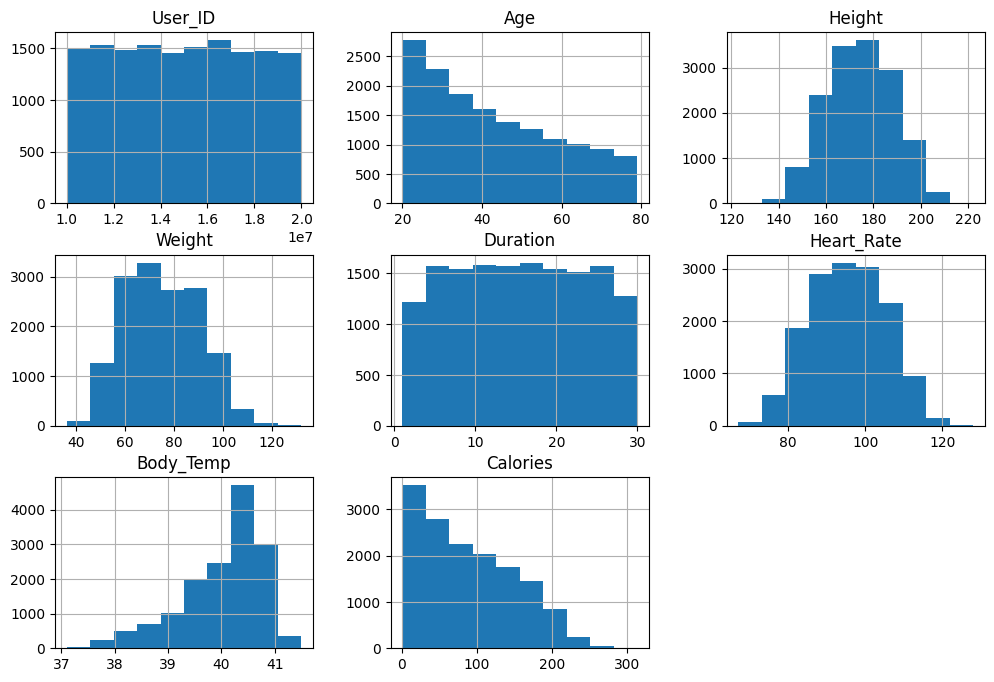

In [39]:
data.hist(figsize=(12,8),bins=10)

In [40]:
data_no_Gender=data.drop(columns="Gender")
data_no_Gender.head()
data_no_Gender.describe()


,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


In [41]:
data_no_Gender.corr()


,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
User_ID,1.000000,-0.001827,-0.013520,-0.011603,-0.002751,-0.000457,0.000923,-0.001661
Age,-0.001827,1.000000,0.009554,0.090094,0.013247,0.010482,0.013175,0.154395
Height,-0.013520,0.009554,1.000000,0.958451,-0.004625,0.000528,0.001200,0.017537
Weight,-0.011603,0.090094,0.958451,1.000000,-0.001884,0.004311,0.004095,0.035481
Duration,-0.002751,0.013247,-0.004625,-0.001884,1.000000,0.852869,0.903167,0.955421
Heart_Rate,-0.000457,0.010482,0.000528,0.004311,0.852869,1.000000,0.771529,0.897882
Body_Temp,0.000923,0.013175,0.001200,0.004095,0.903167,0.771529,1.000000,0.824558
Calories,-0.001661,0.154395,0.017537,0.035481,0.955421,0.897882,0.824558,1.000000


In [42]:
data_numerical=data_no_Gender
data_cato=data[["Gender"]]
print(data_cato)

       Gender
0        male
1      female
2        male
3      female
4      female
...       ...
14995  female
14996  female
14997  female
14998    male
14999    male

[15000 rows x 1 columns]


In [43]:
from sklearn.preprocessing import OneHotEncoder

In [44]:
encoder =OneHotEncoder(sparse_output=False)

encoded=encoder.fit_transform(data_cato)
print(encoded)
encodedDataFrame=pd.DataFrame(encoded)

[[0. 1.]
 [1. 0.]
 [0. 1.]
 ...
 [1. 0.]
 [0. 1.]
 [0. 1.]]


In [45]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data_numerical["Gender"] = le.fit_transform(data[["Gender"]])


c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [46]:
X = data_numerical.drop("User_ID", axis=1)
X = X.drop("Calories", axis=1)
Y=data_numerical[["Calories"]]
X.head()


,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Gender
0,68,190.0,94.0,29.0,105.0,40.8,1
1,20,166.0,60.0,14.0,94.0,40.3,0
2,69,179.0,79.0,5.0,88.0,38.7,1
3,34,179.0,71.0,13.0,100.0,40.5,0
4,27,154.0,58.0,10.0,81.0,39.8,0


In [47]:

X.corr()

,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Gender
Age,1.000000,0.009554,0.090094,0.013247,0.010482,0.013175,0.003222
Height,0.009554,1.000000,0.958451,-0.004625,0.000528,0.001200,0.710534
Weight,0.090094,0.958451,1.000000,-0.001884,0.004311,0.004095,0.783186
Duration,0.013247,-0.004625,-0.001884,1.000000,0.852869,0.903167,0.003440
Heart_Rate,0.010482,0.000528,0.004311,0.852869,1.000000,0.771529,0.011555
Body_Temp,0.013175,0.001200,0.004095,0.903167,0.771529,1.000000,0.007264
Gender,0.003222,0.710534,0.783186,0.003440,0.011555,0.007264,1.000000


In [48]:
Y.head()

,Calories
0,231.0
1,66.0
2,26.0
3,71.0
4,35.0


In [50]:
Y.describe()

,Calories
count,15000.000000
mean,89.539533
std,62.456978
min,1.000000
25%,35.000000
50%,79.000000
75%,138.000000
max,314.000000


In [51]:
Y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Calories  15000 non-null  float64
dtypes: float64(1)
memory usage: 117.3 KB


In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42
)


In [54]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np



model = LinearRegression()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)

print("Mean Squared Error:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R^2 Score:", r2_score(y_test, y_pred))

Mean Squared Error: 11.488940149152876
R^2 Score: 0.9672937151257295


In [55]:
print(model.coef_)
print(model.intercept_)

[[  0.50151302  -0.16965859   0.28630715   6.62800017   1.99086136
  -16.94248834  -1.37420282]]
[461.86268151]


In [56]:
import joblib

joblib.dump(model, "calorie_predictor.pkl")

['calorie_predictor.pkl']